<a href="https://colab.research.google.com/github/essbairidwan/Business-Intelligence/blob/main/immobilier_maroc_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Analyse du Marché Immobilier Marocain
## Exploration, Visualisations Interactives & Prévision des Prix

**Données** : 37 333 annonces immobilières | **Villes** : Agadir, Casablanca, Fès, Marrakech, Rabat, Tanger | **Période** : 2020–2026

---
###  Plan du Notebook
1. **Import & Nettoyage** — Chargement, typage, features engineering
2. **EDA Univariée** — Distributions, outliers, statistiques descriptives
3. **EDA Bivariée & Multivariée** — Prix vs. ville, type, standing, chambres, superficie
4. **Analyse Temporelle** — Évolution des prix 2020–2026
5. **Feature Engineering avancé** — Encodage, normalisation
6. **Modélisation & Prévision** — RandomForest, XGBoost,...,*italicized text* SARIMA / Prophet
7. **Évaluation & Interprétation** — SHAP, importance des variables

---
## 1. Import des Bibliothèques & Chargement des Données

In [5]:
# ── Bibliothèques standard ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# ── Visualisations interactives ─────────────────────────────────────────────
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline




import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)
print('✅ TensorFlow', tf.__version__, 'prêt')

# ── Série temporelle ────────────────────────────────────────────────────────
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print('✅ Prophet disponible')
except ImportError:
    PROPHET_AVAILABLE = False
    print('⚠️  Prophet non installé — fallback sur rolling stats.  pip install prophet')

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✅ XGBoost disponible')
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost non installé.  pip install xgboost')

try:
    import shap
    SHAP_AVAILABLE = True
    print('✅ SHAP disponible')
except ImportError:
    SHAP_AVAILABLE = False
    print('⚠️  SHAP non installé.  pip install shap')

print('\n🎯 Environnement prêt!')

✅ TensorFlow 2.20.0 prêt
✅ Prophet disponible
✅ XGBoost disponible
✅ SHAP disponible

🎯 Environnement prêt!


In [4]:
from google.colab import files
uploaded = files.upload()  # select data_national_immobilier.csv

Saving data_national_immobilier.csv to data_national_immobilier.csv


In [6]:
# ── Chargement ──────────────────────────────────────────────────────────────
DATA = 'data_national_immobilier.csv'   # ← adaptez le chemin si nécessaire

df_raw = pd.read_csv(DATA)
print(f'Dimensions brutes : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
df_raw.head(10)

Dimensions brutes : 37,333 lignes × 15 colonnes


,prix,superficie,prix_par_m2,ville,quartier,type_bien,standing,nb_chambres,nb_salles_bain,etage,parking,ascenseur,terrasse,date_publication,annee
0,"1,310,000",298.4,"4,390",Fes,Adarissa,Maison,Economique,2,2,0,0,0,1,2022-07-05,2022
1,"1,010,000",91.9,"10,990",Agadir,Cite Dakhla,Appartement,Haut standing,2,2,2,0,0,0,2025-10-26,2025
2,"2,250,000",153.5,"14,658",Fes,Saiss,Maison,Moyen,2,2,0,0,0,0,2026-04-05,2026
3,"1,510,000",184.0,"8,207",Tanger,Bni Makada,Appartement,Moyen,3,3,2,0,0,0,2024-02-01,2024
4,"770,000",38.9,"19,794",Casablanca,Racine,Studio,Economique,1,1,5,0,0,0,2021-03-26,2021
5,"6,876,000",117.0,"58,769",Rabat,Hassan,Appartement,Haut standing,2,2,1,1,1,0,2026-02-05,2026
6,"1,150,000",90.6,"12,693",Marrakech,Medina,Appartement,Economique,1,1,3,1,0,1,2024-06-02,2024
7,"6,490,000",174.7,"37,149",Casablanca,CIL,Maison,Haut standing,4,4,0,1,0,1,2026-04-08,2026
8,"913,000",157.8,"5,786",Tanger,Mesnana,Maison,Economique,5,5,0,0,0,1,2023-04-03,2023
9,"1,660,000",35.0,"47,429",Marrakech,Victor Hugo,Appartement,Luxe,2,2,4,1,1,1,2025-06-13,2025


---
## 2. Nettoyage & Feature Engineering

In [7]:
df = df_raw.copy()

# ── 2.1 Types numériques ────────────────────────────────────────────────────
# Les colonnes prix et prix_par_m2 contiennent des virgules comme séparateurs de milliers
df['prix']        = df['prix'].astype(str).str.replace(',', '').astype(float)
df['prix_par_m2'] = df['prix_par_m2'].astype(str).str.replace(',', '').astype(float)

# ── 2.2 Dates ───────────────────────────────────────────────────────────────
df['date_publication'] = pd.to_datetime(df['date_publication'])
df['annee']   = df['date_publication'].dt.year
df['mois']    = df['date_publication'].dt.month
df['trimestre'] = df['date_publication'].dt.quarter
df['periode'] = df['date_publication'].dt.to_period('Q').astype(str)  # ex: 2022Q3

# ── 2.3 Colonnes binaires propres ───────────────────────────────────────────
for col in ['parking', 'ascenseur', 'terrasse']:
    df[col] = df[col].astype(bool)

# ── 2.4 Variables dérivées utiles ───────────────────────────────────────────
df['superficie_par_chambre'] = (df['superficie'] / df['nb_chambres']).round(1)
df['ratio_sdb_chambre']      = (df['nb_salles_bain'] / df['nb_chambres']).round(2)
df['log_prix']               = np.log1p(df['prix'])
df['log_superficie']         = np.log1p(df['superficie'])
df['amenities_score']        = df[['parking','ascenseur','terrasse']].sum(axis=1)

# ── 2.5 Ordinal standing ────────────────────────────────────────────────────
standing_order = {'Economique': 1, 'Moyen': 2, 'Haut standing': 3, 'Luxe': 4}
df['standing_num'] = df['standing'].map(standing_order)

# ── 2.6 Suppression des outliers extrêmes (>99.5e percentile) ───────────────
p_high = df['prix'].quantile(0.995)
p_low  = df['prix'].quantile(0.005)
df_clean = df[(df['prix'] >= p_low) & (df['prix'] <= p_high)].copy()
print(f'Après nettoyage : {len(df_clean):,} lignes  (supprimé {len(df)-len(df_clean)} outliers extrêmes)')

# ── Résumé ──────────────────────────────────────────────────────────────────
print('\n── Valeurs manquantes ──')
print(df_clean.isnull().sum())
df_clean.describe(include='all').T

Après nettoyage : 36,973 lignes  (supprimé 360 outliers extrêmes)

── Valeurs manquantes ──
prix                      0
superficie                0
prix_par_m2               0
ville                     0
quartier                  0
type_bien                 0
standing                  0
nb_chambres               0
nb_salles_bain            0
etage                     0
parking                   0
ascenseur                 0
terrasse                  0
date_publication          0
annee                     0
mois                      0
trimestre                 0
periode                   0
superficie_par_chambre    0
ratio_sdb_chambre         0
log_prix                  0
log_superficie            0
amenities_score           0
standing_num              0
dtype: int64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
prix,36973.0,NaN,NaN,NaN,4345856.111216,190000.0,1150000.0,2320000.0,4750000.0,49880000.0,6131351.00353
superficie,36973.0,NaN,NaN,NaN,129.335856,28.0,72.5,109.2,162.3,692.9,84.907991
prix_par_m2,36973.0,NaN,NaN,NaN,30327.419603,2288.0,12700.0,22734.0,39686.0,263000.0,25105.004973
ville,36973,6,Casablanca,11326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quartier,36973,60,Centre ville,1369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_bien,36973,4,Appartement,18358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standing,36973,4,Moyen,15015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nb_chambres,36973.0,NaN,NaN,NaN,2.6181,1.0,2.0,3.0,3.0,8.0,1.266155
nb_salles_bain,36973.0,NaN,NaN,NaN,2.570335,1.0,2.0,3.0,3.0,5.0,1.194948
etage,36973.0,NaN,NaN,NaN,1.804749,0.0,0.0,1.0,3.0,10.0,2.318002


---
## 3. Analyse Exploratoire — Distributions & Statistiques Descriptives

In [8]:
# ── 3.1 Distribution des Prix ───────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Distribution des Prix (MAD)', 'Distribution log(Prix)']
)

fig.add_trace(
    go.Histogram(x=df_clean['prix']/1e6, nbinsx=80, name='Prix (M MAD)',
                 marker_color='#2563EB', opacity=0.75),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=df_clean['log_prix'], nbinsx=80, name='log(Prix)',
                 marker_color='#059669', opacity=0.75),
    row=1, col=2
)
fig.update_layout(title='Distribution des Prix Immobiliers', height=400, showlegend=False)
fig.update_xaxes(title_text='Prix (Millions MAD)', row=1, col=1)
fig.update_xaxes(title_text='log(Prix)', row=1, col=2)
fig.show()

In [9]:
# ── 3.2 Prix par ville — Violin + Box ───────────────────────────────────────
fig = px.violin(
    df_clean, x='ville', y='prix', color='ville',
    box=True, points=False,
    title='Distribution des Prix par Ville',
    labels={'prix': 'Prix (MAD)', 'ville': 'Ville'},
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_layout(height=500, showlegend=False)
fig.show()

# New Section

In [10]:
# ── 3.3 Prix/m² par ville ───────────────────────────────────────────────────
ppm2_ville = (df_clean.groupby('ville')['prix_par_m2']
                .agg(['median','mean','std'])
                .reset_index()
                .sort_values('median', ascending=False))

fig = go.Figure()
fig.add_trace(go.Bar(
    x=ppm2_ville['ville'], y=ppm2_ville['median'],
    name='Médiane',
    marker_color=px.colors.qualitative.Bold[:len(ppm2_ville)],
    error_y=dict(type='data', array=ppm2_ville['std'], visible=True)
))
fig.add_trace(go.Scatter(
    x=ppm2_ville['ville'], y=ppm2_ville['mean'],
    mode='markers', name='Moyenne',
    marker=dict(size=12, color='black', symbol='diamond')
))
fig.update_layout(
    title='Prix Médian au m² par Ville (±1 écart-type)',
    yaxis_title='Prix/m² (MAD)', height=450
)
fig.show()

In [11]:
# ── 3.4 Répartition par type de bien & standing ─────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'pie'}, {'type': 'pie'}]],
    subplot_titles=['Type de bien', 'Standing']
)

tb_counts = df_clean['type_bien'].value_counts()
st_counts = df_clean['standing'].value_counts()

fig.add_trace(go.Pie(labels=tb_counts.index, values=tb_counts.values,
                     hole=0.4, name='Type'), row=1, col=1)
fig.add_trace(go.Pie(labels=st_counts.index, values=st_counts.values,
                     hole=0.4, name='Standing'), row=1, col=2)
fig.update_layout(title='Composition du Stock Immobilier', height=420)
fig.show()

In [12]:
# ── 3.5 Heatmap prix médian : Ville × Nb chambres ───────────────────────────
heat = (df_clean[df_clean['nb_chambres'] <= 6]
          .groupby(['ville','nb_chambres'])['prix']
          .median()
          .unstack('nb_chambres')
          .fillna(0) / 1e6)

fig = px.imshow(
    heat, text_auto='.1f',
    color_continuous_scale='Blues',
    title='Prix Médian (M MAD) — Ville × Nombre de Chambres',
    labels=dict(x='Nb Chambres', y='Ville', color='Prix médian (M MAD)')
)
fig.update_layout(height=380)
fig.show()

In [13]:
# ── 3.6 Scatter Prix vs Superficie colorié par ville ────────────────────────
fig = px.scatter(
    df_clean.sample(min(5000, len(df_clean)), random_state=42),
    x='superficie', y='prix',
    color='ville', symbol='type_bien',
    opacity=0.55, size_max=7,
    log_x=True, log_y=True,
    trendline='ols', trendline_scope='overall',
    title='Prix vs Superficie par Ville & Type de Bien (axes log)',
    labels={'superficie': 'Superficie (m²)', 'prix': 'Prix (MAD)'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    hover_data=['quartier','standing','nb_chambres']
)
fig.update_layout(height=550)
fig.show()

In [14]:
# ── 3.7 Box : Prix par type_bien × standing ─────────────────────────────────
fig = px.box(
    df_clean, x='type_bien', y='prix', color='standing',
    category_orders={'standing': ['Economique','Moyen','Haut standing','Luxe']},
    title='Distribution des Prix — Type de Bien × Standing',
    labels={'prix': 'Prix (MAD)', 'type_bien': 'Type de bien'},
    color_discrete_sequence=px.colors.sequential.Blues[2:]
)
fig.update_layout(height=520)
fig.show()

In [15]:
# ── 3.8 Corrélation Pearson — variables numériques ──────────────────────────
num_cols = ['prix','superficie','prix_par_m2','nb_chambres','nb_salles_bain',
            'etage','standing_num','amenities_score','superficie_par_chambre']
corr = df_clean[num_cols].corr().round(2)

fig = px.imshow(
    corr, text_auto=True, color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Matrice de Corrélation des Variables Numériques'
)
fig.update_layout(height=550)
fig.show()

In [16]:
# ── 3.9 Prix/m² par quartier (top 20 médiane la plus élevée) ────────────────
q_stats = (df_clean.groupby(['ville','quartier'])['prix_par_m2']
             .agg(mediane='median', count='count')
             .reset_index()
             .query('count >= 30')
             .sort_values('mediane', ascending=False)
             .head(20))
q_stats['label'] = q_stats['ville'] + ' — ' + q_stats['quartier']

fig = px.bar(
    q_stats.sort_values('mediane'), x='mediane', y='label', color='ville',
    orientation='h',
    title='Top 20 Quartiers les Plus Chers (Prix/m² médian)',
    labels={'mediane': 'Prix/m² médian (MAD)', 'label': ''},
    text='mediane', color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=600, showlegend=True)
fig.show()

---
## 4. Analyse Temporelle — Évolution des Prix 2020–2026

In [17]:
# ── 4.1 Évolution annuelle globale ──────────────────────────────────────────
annual = (df_clean.groupby('annee')
            .agg(
                prix_median=('prix','median'),
                prix_moyen=('prix','mean'),
                ppm2_median=('prix_par_m2','median'),
                nb_annonces=('prix','count')
            ).reset_index())

annual['var_annuelle_%'] = annual['prix_median'].pct_change() * 100

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Prix Médian (MAD)', 'Prix/m² Médian (MAD)',
        'Variation Annuelle (%)', 'Volume Annonces'
    ]
)

fig.add_trace(go.Scatter(x=annual['annee'], y=annual['prix_median'],
    mode='lines+markers', name='Médian', line=dict(color='#2563EB', width=3),
    marker=dict(size=8)), row=1, col=1)
fig.add_trace(go.Scatter(x=annual['annee'], y=annual['prix_moyen'],
    mode='lines+markers', name='Moyen', line=dict(color='#7C3AED', width=2,
    dash='dash')), row=1, col=1)

fig.add_trace(go.Scatter(x=annual['annee'], y=annual['ppm2_median'],
    mode='lines+markers', name='Prix/m²', line=dict(color='#059669', width=3),
    marker=dict(size=8)), row=1, col=2)

colors_var = ['#DC2626' if v < 0 else '#059669' for v in annual['var_annuelle_%'].fillna(0)]
fig.add_trace(go.Bar(x=annual['annee'], y=annual['var_annuelle_%'],
    name='Variation %', marker_color=colors_var), row=2, col=1)

fig.add_trace(go.Bar(x=annual['annee'], y=annual['nb_annonces'],
    name='Annonces', marker_color='#F59E0B'), row=2, col=2)

fig.update_layout(title='Évolution Annuelle du Marché Immobilier Marocain',
                  height=600, showlegend=True)
fig.show()
print(annual.to_string(index=False))

 annee  prix_median   prix_moyen  ppm2_median  nb_annonces  var_annuelle_%
  2020    2520000.0 4.599054e+06      23750.0         2961             NaN
  2021    2250000.0 4.273435e+06      21814.0         3700      -10.714286
  2022    2242500.0 4.299493e+06      22538.5         5530       -0.333333
  2023    2310000.0 4.234067e+06      22489.0         6663        3.010033
  2024    2295000.0 4.280673e+06      22508.5         7396       -0.649351
  2025    2420000.0 4.527448e+06      23335.0         5180        5.446623
  2026    2350000.0 4.356846e+06      23125.0         5543       -2.892562


In [18]:
# ── 4.2 Évolution par ville ──────────────────────────────────────────────────
annual_ville = (df_clean.groupby(['annee','ville'])
                  .agg(prix_median=('prix','median'),
                       ppm2_median=('prix_par_m2','median'))
                  .reset_index())

fig = px.line(
    annual_ville, x='annee', y='ppm2_median',
    color='ville', markers=True,
    title='Évolution du Prix/m² Médian par Ville (2020–2026)',
    labels={'ppm2_median': 'Prix/m² médian (MAD)', 'annee': 'Année'},
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_layout(height=480)
fig.show()

In [19]:
# ── 4.3 Évolution trimestrielle — série temporelle fine ─────────────────────
quarterly = (df_clean.groupby(['periode','ville'])
               .agg(prix_median=('prix','median'),
                    ppm2_median=('prix_par_m2','median'),
                    count=('prix','count'))
               .reset_index()
               .sort_values('periode'))

fig = px.line(
    quarterly, x='periode', y='ppm2_median',
    color='ville', markers=False,
    title='Évolution Trimestrielle du Prix/m² par Ville',
    labels={'ppm2_median': 'Prix/m² médian (MAD)', 'periode': 'Trimestre'},
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_xaxes(tickangle=45)
fig.update_layout(height=480)
fig.show()

In [20]:
# ── 4.4 Heatmap temporelle : variation annuelle par ville ────────────────────
pivot = annual_ville.pivot(index='ville', columns='annee', values='ppm2_median')
pct_change = pivot.pct_change(axis=1) * 100

fig = px.imshow(
    pct_change.round(1), text_auto='.1f',
    color_continuous_scale='RdYlGn', zmin=-15, zmax=15,
    title='Variation Annuelle du Prix/m² par Ville (%)'
)
fig.update_layout(height=360)
fig.show()

In [21]:
# ── 4.5 Évolution par type de bien ──────────────────────────────────────────
annual_type = (df_clean.groupby(['annee','type_bien'])
                 .agg(ppm2_median=('prix_par_m2','median'))
                 .reset_index())

fig = px.area(
    annual_type, x='annee', y='ppm2_median',
    color='type_bien', line_group='type_bien',
    title='Évolution du Prix/m² par Type de Bien',
    labels={'ppm2_median': 'Prix/m² médian (MAD)', 'annee': 'Année'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(height=450)
fig.show()

In [22]:
# ── 4.6 Évolution par nombre de chambres ────────────────────────────────────
annual_ch = (df_clean[df_clean['nb_chambres'] <= 5]
               .groupby(['annee','nb_chambres'])
               .agg(ppm2_median=('prix_par_m2','median'))
               .reset_index())
annual_ch['chambres_label'] = annual_ch['nb_chambres'].astype(str) + ' chambre(s)'

fig = px.line(
    annual_ch, x='annee', y='ppm2_median',
    color='chambres_label', markers=True,
    title='Évolution du Prix/m² selon le Nombre de Chambres',
    labels={'ppm2_median': 'Prix/m² médian (MAD)', 'annee': 'Année'},
    color_discrete_sequence=px.colors.sequential.Viridis_r
)
fig.update_layout(height=460)
fig.show()

---
## 5. Feature Engineering pour la Modélisation

In [23]:
# Installation (Colab/Jupyter)
!pip install category-encoders

import category_encoders as ce
from sklearn.model_selection import train_test_split

# Dataset de travail
df_model = df_clean.copy()

# Features et target
FEATURES = [
    'superficie', 'nb_chambres', 'nb_salles_bain', 'etage',
    'standing_num', 'amenities_score',
    'superficie_par_chambre', 'ratio_sdb_chambre',
    'annee', 'mois', 'trimestre',
    'ville', 'quartier', 'type_bien'
]

TARGET = 'log_prix'

X = df_model[FEATURES]
y = df_model[TARGET]

# Split AVANT encodage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Target Encoding pour les variables à forte cardinalité
te = ce.TargetEncoder(cols=['ville', 'quartier'])

X_train = te.fit_transform(X_train, y_train)
X_test = te.transform(X_test)

# Ordinal Encoding pour faible cardinalité
oe = ce.OrdinalEncoder(cols=['type_bien'])

X_train = oe.fit_transform(X_train)
X_test = oe.transform(X_test)

print(f"Train : {len(X_train):,}")
print(f"Test  : {len(X_test):,}")

print(X_train.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 3.9 MB/s eta 0:00:00
Train : 29,578
Test  : 7,395
       superficie  nb_chambres  nb_salles_bain  etage  standing_num  \
15640        37.0            1               1      1             1   
12363        81.4            2               2      0             4   
33383        37.2            1               1      3             2   
25009       134.6            3               3      0             2   
34783        47.0            1               1      5             3   

       amenities_score  superficie_par_chambre  ratio_sdb_chambre  annee  \
15640                2                    37.0                1.0   2023   
12363                2                    40.7                1.0   2023   
33383                1                    37.2                1.0   2023   
25009                1                    44.9                1.0   2025   
34783                1                    47.0                1.0   2025   

       mo

---
## 6. Modélisation — Prédiction des Prix

In [24]:
# ── Fonction d'évaluation ────────────────────────────────────────────────────
def evaluate(name, y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:30s}  MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  R²={r2:.4f}  MAPE={mape:.1f}%')
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = []

# ── 6.1 Ridge Regression (baseline) ─────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

ridge = Ridge(alpha=10)
ridge.fit(X_train_sc, y_train)
results.append(evaluate('Ridge Regression', y_test, ridge.predict(X_test_sc)))

Ridge Regression                MAE=     895,437  RMSE=   2,568,986  R²=0.8158  MAPE=18.9%


In [25]:
# ── 6.2 Random Forest ───────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=300, max_depth=20,
    min_samples_leaf=3, n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
results.append(evaluate('Random Forest', y_test, rf.predict(X_test)))

Random Forest                   MAE=     435,318  RMSE=     940,353  R²=0.9753  MAPE=10.3%


In [26]:
# ── 6.3 Gradient Boosting ───────────────────────────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators=400, learning_rate=0.05,
    max_depth=6, subsample=0.8, random_state=42
)
gb.fit(X_train, y_train)
results.append(evaluate('Gradient Boosting', y_test, gb.predict(X_test)))

Gradient Boosting               MAE=     375,803  RMSE=     809,287  R²=0.9817  MAPE=8.8%


In [27]:
# ── 6.4 XGBoost (si disponible) ─────────────────────────────────────────────
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05,
        max_depth=7, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)], verbose=False)
    results.append(evaluate('XGBoost', y_test, xgb_model.predict(X_test)))
else:
    print('XGBoost non disponible — installez avec: pip install xgboost')

XGBoost                         MAE=     375,420  RMSE=     810,478  R²=0.9817  MAPE=8.9%


CATBOOST

In [28]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [29]:
# ── 6.x CatBoost ────────────────────────────────────────────────────────────
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    random_state=42,
    verbose=0          # silencieux (sinon affiche 400 lignes)
)
cat_model.fit(X_train, y_train)
results.append(evaluate('CatBoost', y_test, cat_model.predict(X_test)))

CatBoost                        MAE=     363,455  RMSE=     784,642  R²=0.9828  MAPE=8.7%


In [30]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # masque les logs techniques de TF

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)   # pour des résultats reproductibles
print('✅ TensorFlow', tf.__version__, 'prêt')

✅ TensorFlow 2.20.0 prêt


In [31]:
from sklearn.preprocessing import StandardScaler

# On réutilise X_train / X_test déjà créés à votre Section 5
scaler_mlp = StandardScaler()
X_train_sc = scaler_mlp.fit_transform(X_train)   # apprend + transforme
X_test_sc  = scaler_mlp.transform(X_test)        # transforme uniquement

n_features = X_train_sc.shape[1]

print(f'✅ Données standardisées')
print(f'   X_train_sc : {X_train_sc.shape}')
print(f'   X_test_sc  : {X_test_sc.shape}')
print(f'   Nombre de features : {n_features}')

✅ Données standardisées
   X_train_sc : (29578, 14)
   X_test_sc  : (7395, 14)
   Nombre de features : 14


In [33]:
print("X_test_sc existe ?", 'X_test_sc' in dir())
print("Forme X_test    :", X_test.shape)
print("Moyenne X_test_sc (doit être ~0) :", X_test_sc.mean().round(3) if 'X_test_sc' in dir() else "N/A")

# Re-prédiction propre du MLP
y_pred_mlp = mlp.predict(X_test_sc, verbose=0).flatten()
from sklearn.metrics import r2_score
print("R² recalculé :", round(r2_score(np.expm1(y_test), np.expm1(y_pred_mlp)), 4))

X_test_sc existe ? True
Forme X_test    : (7395, 14)
Moyenne X_test_sc (doit être ~0) : -0.008


NameError: name 'mlp' is not defined

In [34]:
def build_mlp(n_inputs):
    model = keras.Sequential([
        keras.Input(shape=(n_inputs,)),       # couche d'entrée : 14 features

        layers.Dense(256, activation='relu'), # couche cachée 1
        layers.BatchNormalization(),          # stabilise l'apprentissage
        layers.Dropout(0.3),                  # désactive 30% des neurones (anti-surapprentissage)

        layers.Dense(128, activation='relu'), # couche cachée 2
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(64, activation='relu'),  # couche cachée 3
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu'),  # couche cachée 4

        layers.Dense(1)                        # sortie : 1 valeur = log_prix
    ], name='MLP_Immobilier')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='huber',        # robuste aux prix extrêmes
        metrics=['mae']
    )
    return model

mlp = build_mlp(n_features)
mlp.summary()

Model: "MLP_Immobilier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,897 (191.00 KB)

 Trainable params: 48,001 (187.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [35]:
# ── Deux garde-fous pendant l'entraînement ──────────────────────────────
callbacks = [
    # Arrête l'entraînement si la validation ne progresse plus pendant 15 époques
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True),

    # Réduit le learning rate de moitié si on stagne (apprentissage plus fin)
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-5)
]

# ── Lancement de l'entraînement ─────────────────────────────────────────
history = mlp.fit(
    X_train_sc, y_train,
    validation_split=0.15,   # 15% du train sert à valider à chaque époque
    epochs=120,
    batch_size=256,
    callbacks=callbacks,
    verbose=1                # affiche la progression
)

print('\n✅ Entraînement terminé !')

Epoch 1/120
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 7.1624 - mae: 7.6467 - val_loss: 3.4147 - val_mae: 3.9147 - learning_rate: 0.0010
Epoch 2/120
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0369 - mae: 1.4639 - val_loss: 0.7876 - val_mae: 1.2562 - learning_rate: 0.0010
Epoch 3/120
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8126 - mae: 1.2268 - val_loss: 0.2268 - val_mae: 0.5774 - learning_rate: 0.0010
Epoch 4/120
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7222 - mae: 1.1295 - val_loss: 0.1012 - val_mae: 0.3635 - learning_rate: 0.0010
Epoch 5/120
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6583 - mae: 1.0594 - val_loss: 0.0831 - val_mae: 0.3321 - learning_rate: 0.0010
Epoch 6/120
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6358 - mae: 1.0363 - val_loss: 0.1057 - val_mae: 0.3842 - learning_rate: 0.0010
Epoch 7/120
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5967 - mae: 0.9929 - val_loss: 0.0902 - val_mae: 0.3515 - learning_rate: 0.0010
Epoch 8/12

In [36]:
# Prédictions sur le jeu de test (le réseau sort du log_prix)
y_pred_mlp = mlp.predict(X_test_sc, verbose=0).flatten()

# On réutilise VOTRE fonction evaluate() → repasse en DH réels + métriques
res_mlp = evaluate('MLP (Keras)', y_test, y_pred_mlp)

# On ajoute le MLP à votre liste de résultats existante
results.append(res_mlp)

MLP (Keras)                     MAE=     649,296  RMSE=   1,489,880  R²=0.9380  MAPE=13.9%


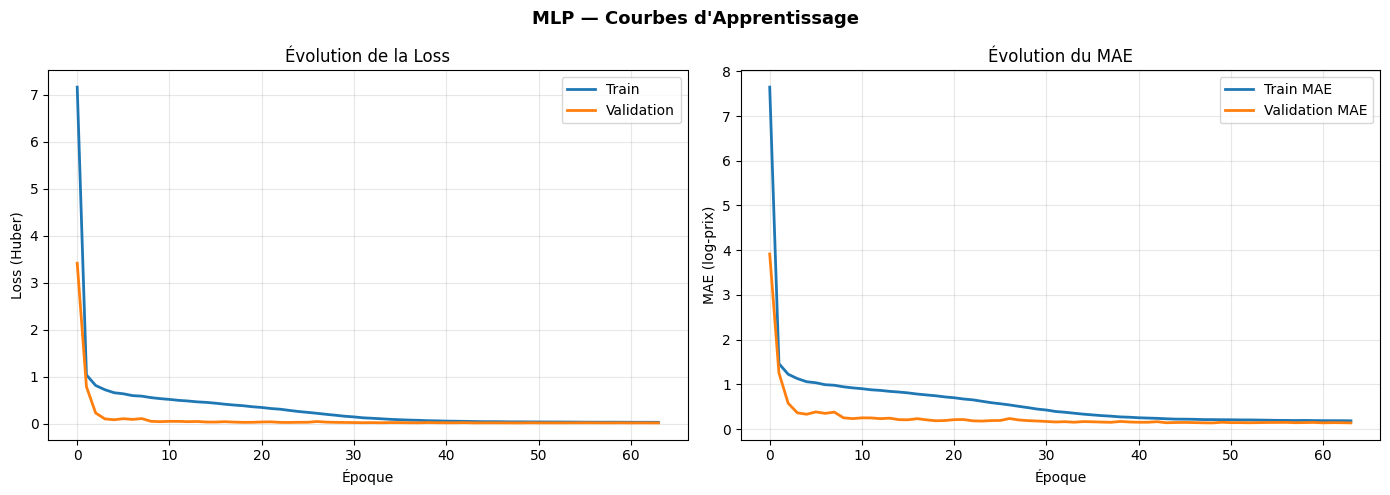

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MLP — Courbes d'Apprentissage", fontsize=13, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'], label='Train', lw=2)
axes[0].plot(history.history['val_loss'], label='Validation', lw=2)
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss (Huber)')
axes[0].set_title('Évolution de la Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', lw=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', lw=2)
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('MAE (log-prix)')
axes[1].set_title('Évolution du MAE'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [38]:
# ── 6.5 Tableau comparatif des modèles ──────────────────────────────────────
df_results = pd.DataFrame(results).sort_values('R2', ascending=False)

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['R² (↑ mieux)', 'MAE (↓ mieux)', 'MAPE % (↓ mieux)'])

colors = px.colors.qualitative.Bold[:len(df_results)]

fig.add_trace(go.Bar(x=df_results['name'], y=df_results['R2'],
    marker_color=colors, name='R²'), row=1, col=1)
fig.add_trace(go.Bar(x=df_results['name'], y=df_results['MAE']/1e6,
    marker_color=colors, name='MAE (M MAD)', showlegend=False), row=1, col=2)
fig.add_trace(go.Bar(x=df_results['name'], y=df_results['MAPE'],
    marker_color=colors, name='MAPE %', showlegend=False), row=1, col=3)

fig.update_layout(title='Comparaison des Modèles', height=420)
fig.show()
print(df_results.to_string(index=False))

             name           MAE         RMSE       R2      MAPE
         CatBoost 363455.160432 7.846420e+05 0.982814  8.701245
Gradient Boosting 375803.128631 8.092870e+05 0.981717  8.841426
          XGBoost 375420.449702 8.104775e+05 0.981663  8.876564
    Random Forest 435317.740924 9.403528e+05 0.975316 10.326854
      MLP (Keras) 649295.623914 1.489880e+06 0.938036 13.850232
 Ridge Regression 895437.022084 2.568986e+06 0.815769 18.865637


In [39]:
# ── 6.6 Predicted vs Actual — meilleur modèle ───────────────────────────────
# Sélectionne le meilleur modèle automatiquement
best_name = df_results.iloc[0]['name']
best_models = {'Ridge Regression': ridge, 'Random Forest': rf,'CatBoost':cat_model,
               'Gradient Boosting': gb}
if XGB_AVAILABLE: best_models['XGBoost'] = xgb_model

best_model = best_models[best_name]
if best_name == 'Ridge Regression':
    y_pred_test = best_model.predict(X_test_sc)
else:
    y_pred_test = best_model.predict(X_test)

y_pred_real = np.expm1(y_pred_test)
y_test_real = np.expm1(y_test)

sample_idx = np.random.choice(len(y_test_real), size=min(2000, len(y_test_real)), replace=False)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=y_test_real.values[sample_idx], y=y_pred_real[sample_idx],
    mode='markers', marker=dict(size=4, color='#2563EB', opacity=0.5),
    name='Prédictions'
))
max_val = max(y_test_real.max(), y_pred_real.max())
fig.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val],
    mode='lines', line=dict(color='red', dash='dash', width=2),
    name='Ligne parfaite'
))
fig.update_layout(
    title=f'{best_name} — Prix Réels vs Prédits',
    xaxis_title='Prix Réel (MAD)', yaxis_title='Prix Prédit (MAD)',
    height=500
)
fig.show()

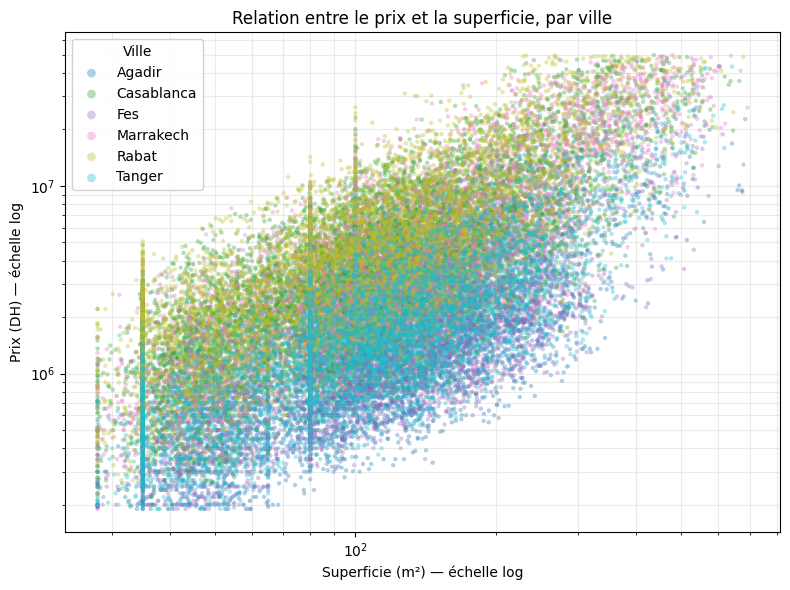

✅ figures/fig_4_prix_superficie.png créé — 36973 points


In [40]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
df = pd.read_csv("data_national_immobilier.csv")   # adapte le chemin si besoin

# --- Nettoyage / conversion en numérique ---
def to_num(serie):
    return pd.to_numeric(
        serie.astype(str)
             .str.replace(r"[^\d.,]", "", regex=True)   # enlève DH, m², espaces…
             .str.replace(" ", "", regex=False)
             .str.replace(",", "", regex=False),          # sépar. de milliers
        errors="coerce")

df["prix"]       = to_num(df["prix"])
df["superficie"] = to_num(df["superficie"])
df = df.dropna(subset=["prix", "superficie"])
df = df[(df["prix"] > 0) & (df["superficie"] > 0)]

# --- Filtrage des prix extrêmes (percentiles 0,5 / 99,5) ---
lo, hi = df["prix"].quantile([0.005, 0.995])
df = df[(df["prix"] >= lo) & (df["prix"] <= hi)]

# --- Tracé log-log coloré par ville ---
villes = sorted(df["ville"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(villes)))

fig, ax = plt.subplots(figsize=(8, 6))
for v, c in zip(villes, colors):
    sub = df[df["ville"] == v]
    ax.scatter(sub["superficie"], sub["prix"], s=10, alpha=0.35,
               color=c, label=v, edgecolors="none")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Superficie (m²) — échelle log")
ax.set_ylabel("Prix (DH) — échelle log")
ax.set_title("Relation entre le prix et la superficie, par ville")
ax.grid(True, which="both", alpha=0.25)
ax.legend(title="Ville", markerscale=2, framealpha=0.9)
plt.tight_layout()
plt.savefig("figures/fig_4_prix_superficie.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ figures/fig_4_prix_superficie.png créé —", len(df), "points")

In [41]:
# ── 6.7 Importance des features (Random Forest) ─────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig = go.Figure(go.Bar(
    x=feat_imp.values, y=feat_imp.index,
    orientation='h', marker_color='#2563EB'
))
fig.update_layout(
    title='Importance des Variables — Random Forest',
    xaxis_title='Importance (Gini)', height=500
)
fig.show()

In [42]:
# ── 6.8 Analyse des résidus ──────────────────────────────────────────────────
residuals = y_test_real - y_pred_real
pct_residuals = residuals / y_test_real * 100

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Résidus (MAD)', 'Résidus relatifs (%)'])

fig.add_trace(go.Histogram(x=residuals/1e6, nbinsx=60,
    marker_color='#7C3AED', opacity=0.75, name='Résidus (M MAD)'),
    row=1, col=1)
fig.add_trace(go.Histogram(x=pct_residuals, nbinsx=60,
    marker_color='#059669', opacity=0.75, name='Résidus %'),
    row=1, col=2)

fig.update_layout(title='Distribution des Résidus', height=420, showlegend=False)
fig.show()

In [43]:
# ── 6.9 SHAP values (si disponible) ─────────────────────────────────────────
'''
if SHAP_AVAILABLE:
    import matplotlib.pyplot as plt
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test.iloc[:500])
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, X_test.iloc[:500], feature_names=FEATURES,
                      plot_type='bar', show=False)
    plt.title('SHAP — Importance des Variables (Random Forest)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('SHAP non disponible — installez avec: pip install shap')
'''

"\nif SHAP_AVAILABLE:\n    import matplotlib.pyplot as plt\n    explainer = shap.TreeExplainer(rf)\n    shap_values = explainer.shap_values(X_test.iloc[:500])\n    plt.figure(figsize=(10,6))\n    shap.summary_plot(shap_values, X_test.iloc[:500], feature_names=FEATURES,\n                      plot_type='bar', show=False)\n    plt.title('SHAP — Importance des Variables (Random Forest)', fontsize=13)\n    plt.tight_layout()\n    plt.show()\nelse:\n    print('SHAP non disponible — installez avec: pip install shap')\n"

In [46]:
import json
with open("mlp_history.json", "w") as f:
    json.dump(history.history, f)

---
## 7. Prévision Temporelle — Prophet / Rolling Forecast

In [47]:
# ── 7.1 Préparation des séries temporelles mensuelles ───────────────────────
monthly_global = (df_clean.resample('ME', on='date_publication')['prix_par_m2']
                    .median()
                    .reset_index()
                    .rename(columns={'date_publication': 'ds', 'prix_par_m2': 'y'}))

monthly_global = monthly_global[monthly_global['y'].notna()]
print(f'Série mensuelle globale : {len(monthly_global)} points ({monthly_global["ds"].min().date()} → {monthly_global["ds"].max().date()})')
monthly_global.tail()

Série mensuelle globale : 78 points (2020-01-31 → 2026-06-30)


,ds,y
73,2026-02-28,24335.5
74,2026-03-31,22690.0
75,2026-04-30,21901.5
76,2026-05-31,23402.0
77,2026-06-30,25461.0


In [48]:
import pandas as pd, numpy as np
from catboost import CatBoostRegressor
from category_encoders import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("data_national_immobilier.csv")   # adapte le chemin

# --- Conversion des colonnes numériques (elles arrivent en texte) ---
def to_num(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(r"[^\d.\-]", "", regex=True),
        errors="coerce")

for col in ["prix","superficie","prix_par_m2","nb_chambres","nb_salles_bain",
            "etage","parking","ascenseur","terrasse","annee"]:
    if col in df.columns:
        df[col] = to_num(df[col])

df = df.dropna(subset=["prix","superficie","annee"])
df = df[df["prix"] > 0]

# --- cible ---
df["log_prix"] = np.log1p(df["prix"])

# --- découpage TEMPOREL : train = 2020-2025, test = 2026 ---
train = df[df["annee"] <= 2025].copy()
test  = df[df["annee"] == 2026].copy()
print(f"Train (2020-2025) : {len(train)}  |  Test (2026) : {len(test)}")

features = ["superficie","ville","quartier","type_bien","standing",
            "nb_chambres","nb_salles_bain","etage","parking","ascenseur","terrasse"]
Xtr, ytr = train[features].copy(), train["log_prix"]
Xte, yte = test[features].copy(),  test["log_prix"]

# --- encodage ajusté sur le TRAIN uniquement (anti-fuite) ---
te = TargetEncoder(cols=["ville","quartier"])
Xtr[["ville","quartier"]] = te.fit_transform(Xtr[["ville","quartier"]], ytr)
Xte[["ville","quartier"]] = te.transform(Xte[["ville","quartier"]])

oe = OrdinalEncoder()
Xtr[["type_bien","standing"]] = oe.fit_transform(Xtr[["type_bien","standing"]])
Xte[["type_bien","standing"]] = oe.transform(Xte[["type_bien","standing"]])

# --- CatBoost avec tes hyperparamètres réels ---
model = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6,
                          l2_leaf_reg=3.0, random_state=42, verbose=0)
model.fit(Xtr, ytr)

# --- métriques sur l'échelle des DIRHAMS ---
pred = np.expm1(model.predict(Xte))
vrai = np.expm1(yte)
print("\n=== Validation temporelle (test = 2026 reel) ===")
print(f"MAE  : {mean_absolute_error(vrai, pred):,.0f} DH")
print(f"RMSE : {np.sqrt(mean_squared_error(vrai, pred)):,.0f} DH")
print(f"R2   : {r2_score(vrai, pred):.4f}")
print(f"MAPE : {np.mean(np.abs((vrai - pred) / vrai)) * 100:.2f} %")

Train (2020-2025) : 31733  |  Test (2026) : 5600

=== Validation temporelle (test = 2026 reel) ===
MAE  : 419,975 DH
RMSE : 1,118,235 DH
R2   : 0.9785
MAPE : 8.71 %


In [49]:
import joblib

artifacts = {
    'model':            cat_model,      # ⬅️ CatBoost (votre meilleur modèle)
    'te':               te,
    'oe':               oe,
    'features':         FEATURES,
    'standing_order':   standing_order,
    'villes':           sorted(df_clean['ville'].unique().tolist()),
    'types':            sorted(df_clean['type_bien'].unique().tolist()),
    'standings':        ['Economique', 'Moyen', 'Haut standing', 'Luxe'],
    'quartiers_par_ville': df_clean.groupby('ville')['quartier']
                            .unique().apply(lambda x: sorted(list(x))).to_dict(),
}
joblib.dump(artifacts, 'immo_artifacts.pkl')
print('✅ immo_artifacts.pkl regénéré avec CatBoost')
print('   Modèle :', type(artifacts['model']).__name__)

✅ immo_artifacts.pkl regénéré avec CatBoost
   Modèle : CatBoostRegressor


In [50]:
from google.colab import files
files.download('immo_artifacts.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

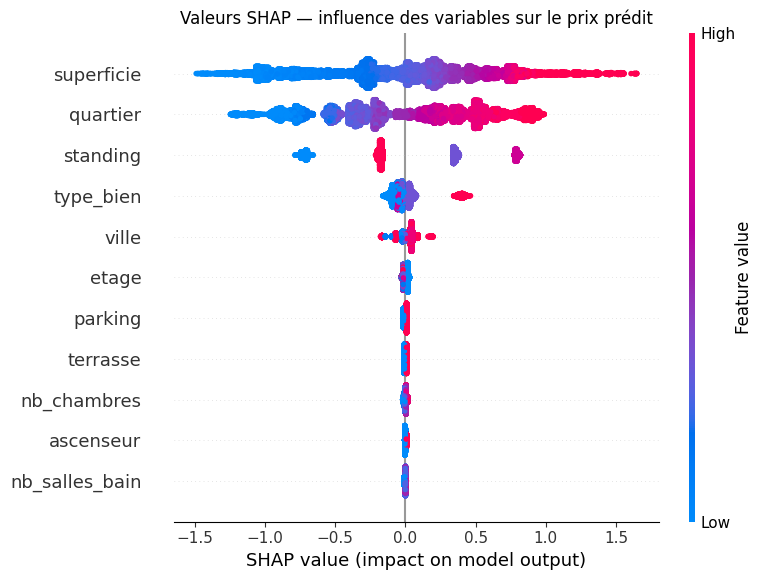

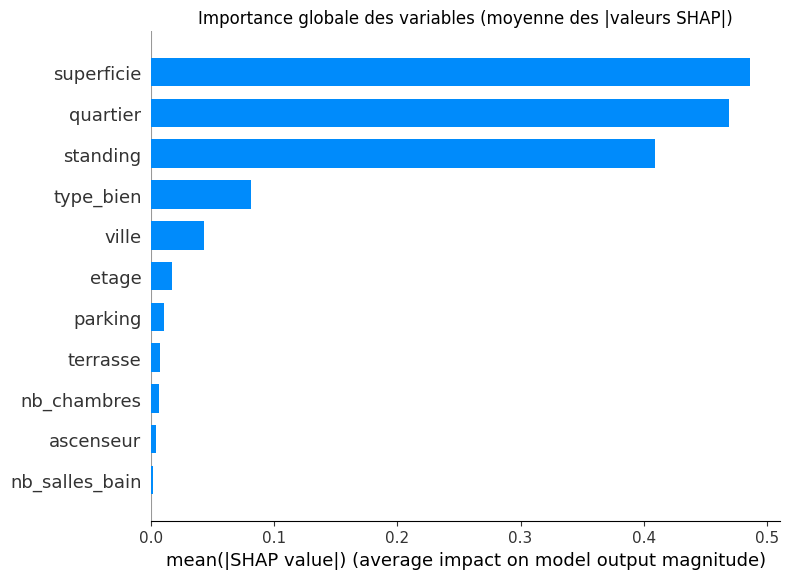

✅ figures/fig_6_shap_summary.png et fig_6_shap_importance.png créés


In [52]:
import shap, numpy as np, matplotlib.pyplot as plt, os
os.makedirs("figures", exist_ok=True)

# model = ton CatBoost entraîné ; Xtr = features d'entraînement encodées (numériques)
# TreeExplainer est exact et rapide pour les modèles à base d'arbres
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(Xtr)

# --- Figure 1 : summary plot (beeswarm) — effet et sens de chaque variable ---
plt.figure()
shap.summary_plot(shap_values, Xtr, show=False, max_display=14)
plt.title("Valeurs SHAP — influence des variables sur le prix prédit")
plt.tight_layout()
plt.savefig("figures/fig_6_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Figure 2 : importance globale (moyenne des |SHAP|) — classement des variables ---
plt.figure()
shap.summary_plot(shap_values, Xtr, plot_type="bar", show=False, max_display=14)
plt.title("Importance globale des variables (moyenne des |valeurs SHAP|)")
plt.tight_layout()
plt.savefig("figures/fig_6_shap_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ figures/fig_6_shap_summary.png et fig_6_shap_importance.png créés")